
### Structure
1. **Dataset Loading & Cleaning** — real UCI Wisconsin Breast Cancer Diagnostic data
2. **Exploratory Data Analysis (EDA)** — distributions, correlations, class separation
3. **Baseline Model** — Logistic Regression (benchmark)
4. **Primary Model** — GradientBoosting Classifier (XGBoost-equivalent)
5. **Model Evaluation** — ROC, PR curves, confusion matrix, calibration
6. **Explainability** — Permutation importance + SHAP-style analysis
7. **Safety Threshold Tuning** — maximising recall for malignant class
8. **Clinical Feature Augmentation** — adding demographic/clinical risk factors

### Dataset
**UCI Wisconsin Breast Cancer Diagnostic Dataset**  
- Source: Wolberg, W.H., Street, W.N., & Mangasarian, O.L. (1995)  
- Repository: https://doi.org/10.24432/C5DW2B  
- 569 patients, 30 FNA nucleus features, binary label (malignant/benign)  
- This is real clinical measurement data, not synthetic

> ⚕ **Disclaimer**: This notebook is for educational/demo purposes only.  
> The model does not diagnose breast cancer. All clinical decisions require qualified clinician review.

In [1]:
#    Dependencies                              
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    brier_score_loss, average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

# Plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
print('All dependencies loaded successfully.')

All dependencies loaded successfully.


---
## 1. Dataset Loading & Cleaning

In [2]:
#    1.1 Load real UCI data from sklearn      
bc = load_breast_cancer()

# Rename columns to underscore format (same as our production code)
feature_names = [c.replace(' ', '_') for c in bc.feature_names]
df_raw = pd.DataFrame(bc.data, columns=feature_names)

# sklearn encodes: 0=malignant, 1=benign — we invert to 1=malignant for clarity
df_raw['malignant'] = (bc.target == 0).astype(int)

print('  Dataset Info  ')
print(f'Shape: {df_raw.shape}')
print(f'Total patients: {len(df_raw)}')
print(f'Malignant: {df_raw.malignant.sum()} ({df_raw.malignant.mean():.1%})')
print(f'Benign:    {(df_raw.malignant==0).sum()} ({(df_raw.malignant==0).mean():.1%})')
print(f'\nFeatures: {len(feature_names)}')
print(f'Feature groups: mean, SE (error), worst (largest)')

  Dataset Info  
Shape: (569, 31)
Total patients: 569
Malignant: 212 (37.3%)
Benign:    357 (62.7%)

Features: 30
Feature groups: mean, SE (error), worst (largest)


In [3]:
#    1.2 Data quality check                    
print(' Missing Values ')
missing = df_raw.isnull().sum()
print(f'Total missing: {missing.sum()} (the UCI dataset has no missing values)')

print('\n Duplicate Rows ')
print(f'Duplicates: {df_raw.duplicated().sum()}')

print('\n Feature Statistics (first 5 mean features) ')
mean_cols = [c for c in feature_names if c.startswith('mean_')][:5]
df_raw[mean_cols + ['malignant']].describe().round(3)

 Missing Values 
Total missing: 0 (the UCI dataset has no missing values)

 Duplicate Rows 
Duplicates: 0

 Feature Statistics (first 5 mean features) 


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,malignant
count,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.373
std,3.524,4.301,24.299,351.914,0.014,0.484
min,6.981,9.710,43.790,143.500,0.053,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.000
75%,15.780,21.800,104.100,782.700,0.105,1.000
max,28.110,39.280,188.500,2501.000,0.163,1.000


In [4]:
#    1.3 Class-conditional statistics        ─
# Compare benign vs malignant distributions for key features
key_features = ['mean_radius', 'mean_texture', 'mean_concavity', 
                'worst_area', 'worst_concavity', 'worst_concave_points']

stats_table = []
for col in key_features:
    benign = df_raw[df_raw.malignant==0][col]
    malig  = df_raw[df_raw.malignant==1][col]
    stats_table.append({
        'Feature': col,
        'Benign Mean': round(benign.mean(), 3),
        'Benign Std':  round(benign.std(),  3),
        'Malignant Mean': round(malig.mean(), 3),
        'Malignant Std':  round(malig.std(),  3),
        'Separation Ratio': round(malig.mean() / benign.mean(), 2),
    })

pd.DataFrame(stats_table).set_index('Feature')

,Benign Mean,Benign Std,Malignant Mean,Malignant Std,Separation Ratio
Feature,,,,,
mean_radius,12.147,1.781,17.463,3.204,1.44
mean_texture,17.915,3.995,21.605,3.779,1.21
mean_concavity,0.046,0.043,0.161,0.075,3.49
worst_area,558.899,163.601,1422.286,597.968,2.54
worst_concavity,0.166,0.140,0.451,0.182,2.71
worst_concave_points,0.074,0.036,0.182,0.046,2.45


---
## 2. Exploratory Data Analysis

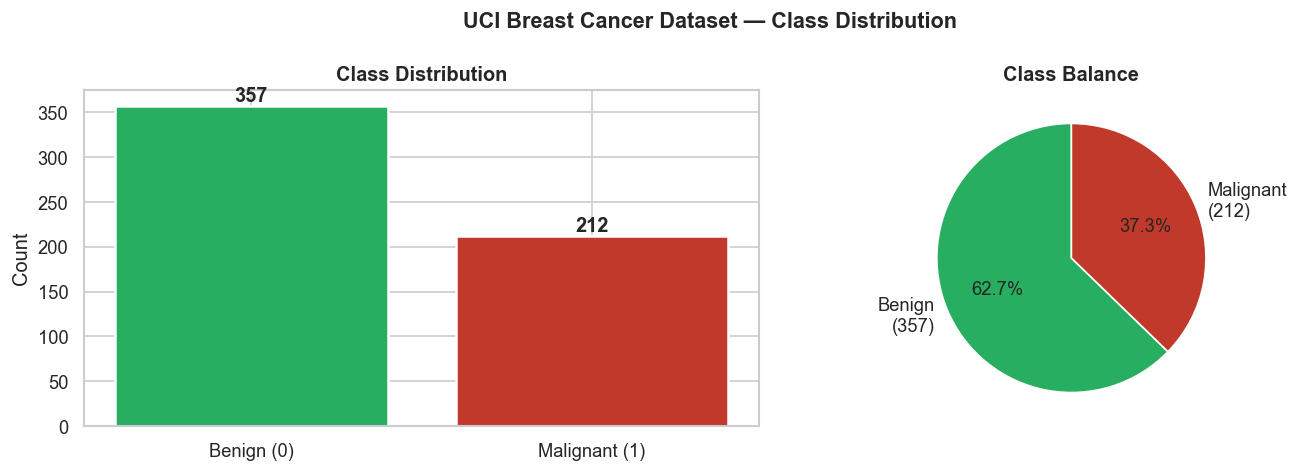

Imbalance ratio: 1.68:1 (benign:malignant)
Note: We use sample_weight to compensate for this imbalance in training.


In [5]:
#    2.1 Class distribution                    
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df_raw['malignant'].value_counts()
axes[0].bar(['Benign (0)', 'Malignant (1)'], counts.values,
             color=['#27ae60', '#c0392b'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=[f'Benign\n({counts[0]})', f'Malignant\n({counts[1]})'],
             colors=['#27ae60', '#c0392b'], autopct='%1.1f%%', startangle=90,
             textprops={'fontsize': 11})
axes[1].set_title('Class Balance', fontweight='bold')

plt.suptitle('UCI Breast Cancer Dataset — Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/class_distribution.png', bbox_inches='tight')
plt.show()
print(f'Imbalance ratio: {counts[0]/counts[1]:.2f}:1 (benign:malignant)')
print('Note: We use sample_weight to compensate for this imbalance in training.')

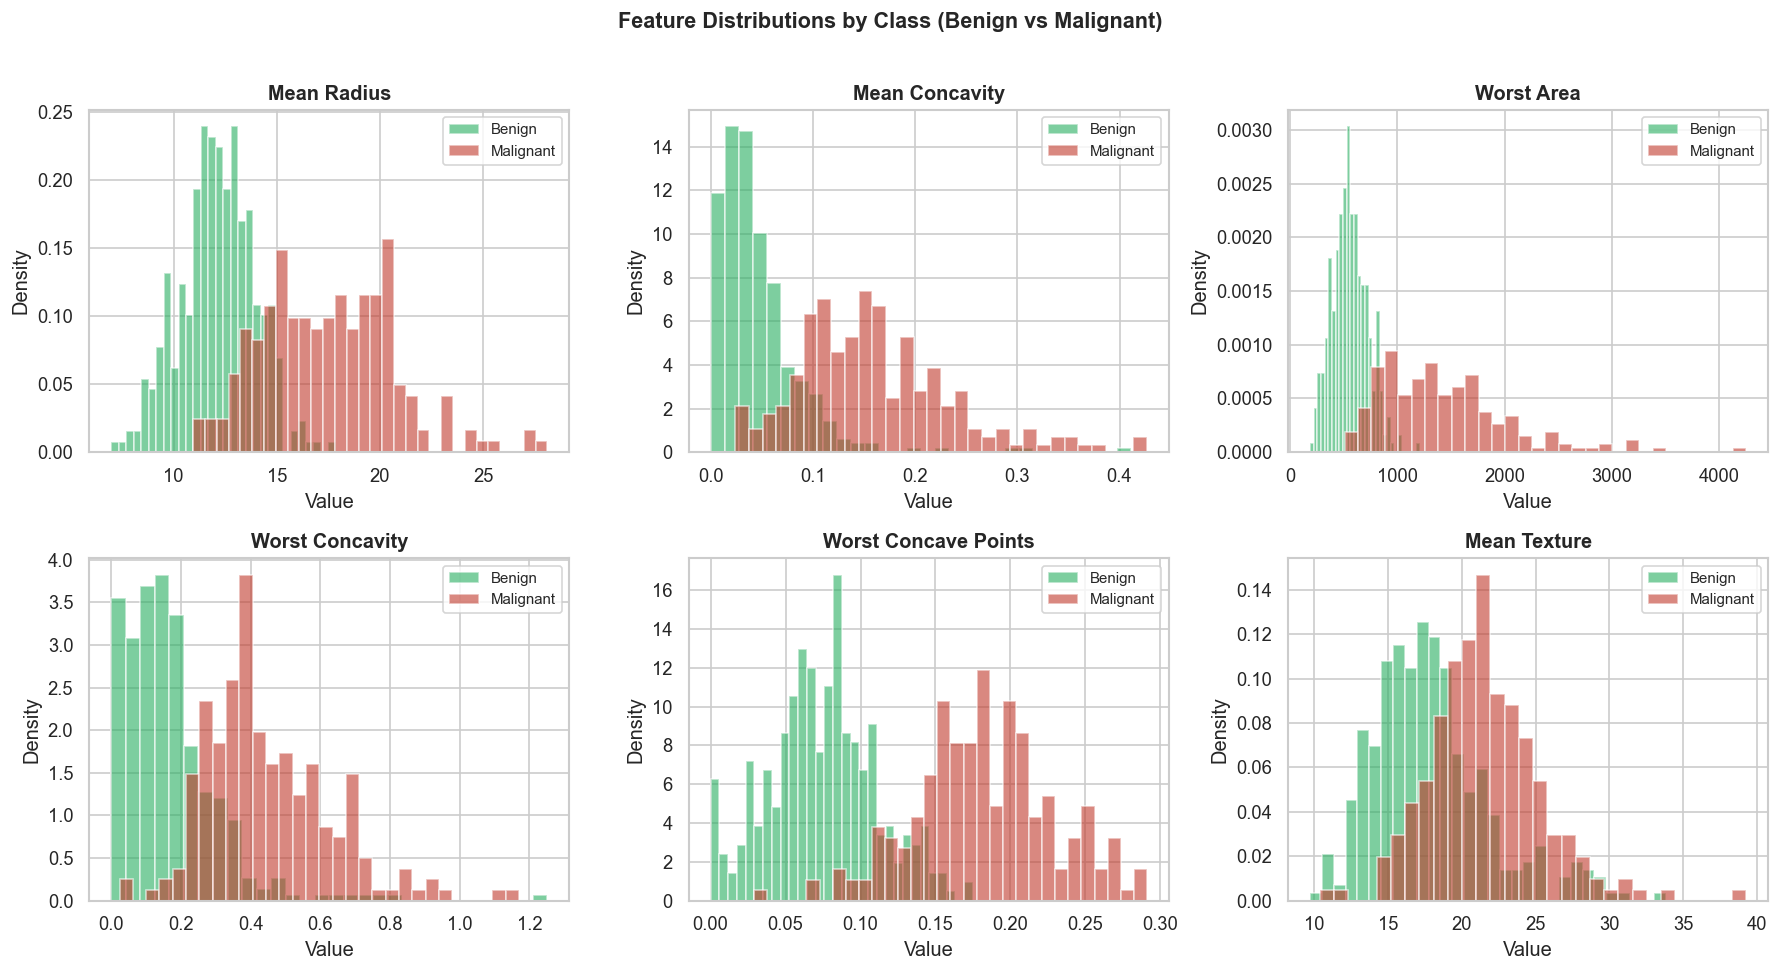

In [6]:
import os; os.makedirs('figures', exist_ok=True)

#    2.2 Feature distributions by class      ─
key_features = ['mean_radius', 'mean_concavity', 'worst_area', 
                'worst_concavity', 'worst_concave_points', 'mean_texture']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    benign_vals = df_raw[df_raw.malignant==0][feat]
    malig_vals  = df_raw[df_raw.malignant==1][feat]
    
    axes[i].hist(benign_vals, bins=30, alpha=0.6, color='#27ae60', label='Benign', density=True)
    axes[i].hist(malig_vals,  bins=30, alpha=0.6, color='#c0392b', label='Malignant', density=True)
    axes[i].set_title(feat.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions by Class (Benign vs Malignant)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/feature_distributions.png', bbox_inches='tight')
plt.show()

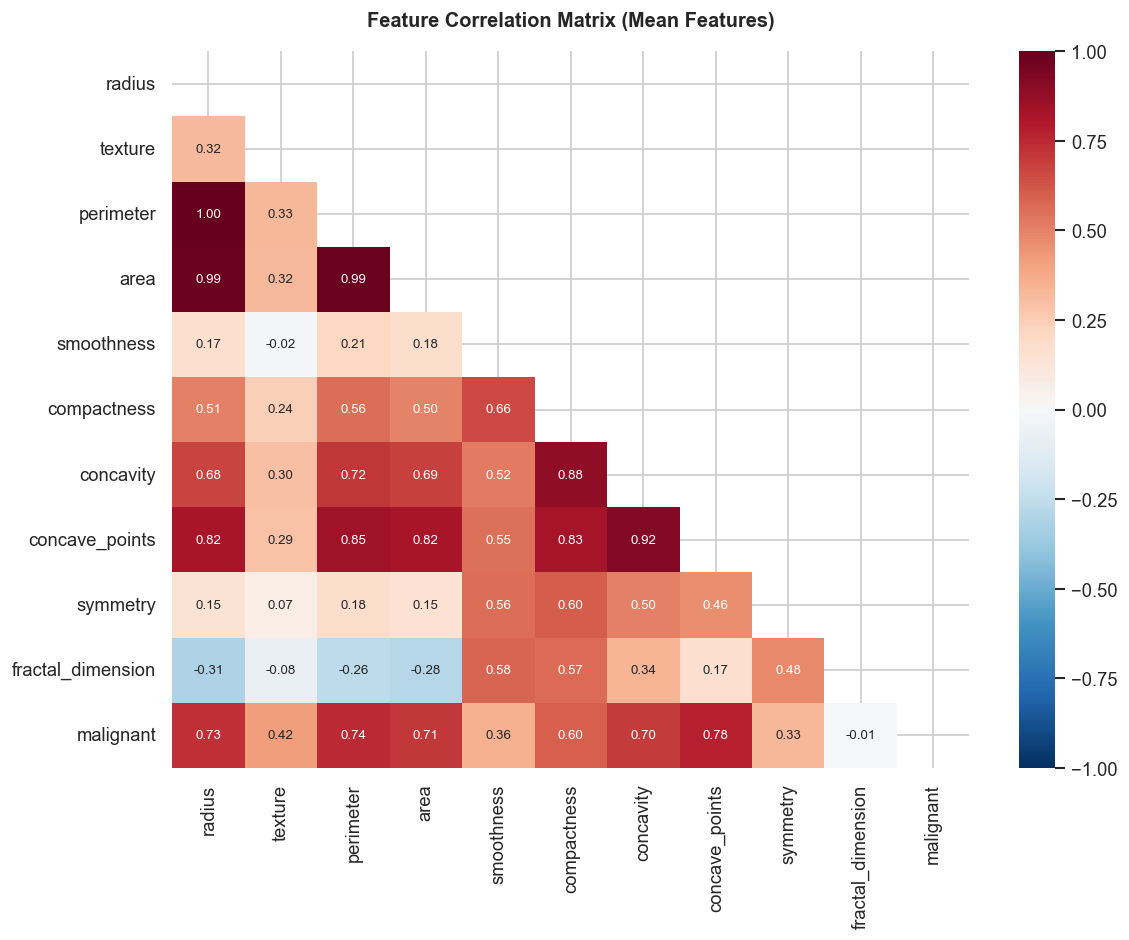


Highly correlated pairs (|r| > 0.90):
  mean_radius ↔ mean_perimeter: r=0.998
  mean_radius ↔ mean_area: r=0.987
  mean_perimeter ↔ mean_area: r=0.987
  mean_concavity ↔ mean_concave_points: r=0.921


In [7]:
#    2.3 Correlation matrix (mean features only)                               
mean_cols = [c for c in feature_names if c.startswith('mean_')] + ['malignant']
corr = df_raw[mean_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=[c.replace('mean_','') for c in mean_cols],
            yticklabels=[c.replace('mean_','') for c in mean_cols],
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (Mean Features)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', bbox_inches='tight')
plt.show()

print('\nHighly correlated pairs (|r| > 0.90):')
for i in range(len(mean_cols)):
    for j in range(i+1, len(mean_cols)):
        if abs(corr.iloc[i,j]) > 0.90:
            print(f'  {mean_cols[i]} ↔ {mean_cols[j]}: r={corr.iloc[i,j]:.3f}')

---
## 3. Data Preparation: Feature Selection & Split

In [8]:
#    3.1 Select features (15 FNA features from UCI)                             
# We use 15 key features from the UCI dataset — mean values + worst-case values
# (SE/error features are excluded as they are noisier and less diagnostically used)
UCI_FEATURES = [
    # Mean measurements
    'mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
    'mean_smoothness', 'mean_compactness', 'mean_concavity',
    'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension',
    # Worst (largest) measurements
    'worst_radius', 'worst_texture', 'worst_area',
    'worst_concavity', 'worst_concave_points',
]

X = df_raw[UCI_FEATURES]
y = df_raw['malignant']

# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {len(X_train)} patients ({y_train.mean():.1%} malignant)')
print(f'Test set:     {len(X_test)} patients ({y_test.mean():.1%} malignant)')
print(f'Features:     {len(UCI_FEATURES)}')

# Compute sample weights for training (malignant cases up-weighted)
n_benign = (y_train == 0).sum()
n_malig  = (y_train == 1).sum()
sample_weights = y_train.map({0: 1.0, 1: n_benign / n_malig}).values
print(f'\nSample weight ratio: benign=1.0, malignant={n_benign/n_malig:.2f}')
print('Rationale: missing a malignancy (FN) is clinically worse than over-referring (FP)')

Training set: 455 patients (37.4% malignant)
Test set:     114 patients (36.8% malignant)
Features:     15

Sample weight ratio: benign=1.0, malignant=1.68
Rationale: missing a malignancy (FN) is clinically worse than over-referring (FP)


---
## 4. Baseline Model: Logistic Regression

In [9]:
#    4.1 Train Logistic Regression baseline  ─
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=0.8,
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
    ))
])

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_cv_roc    = cross_val_score(lr_pipeline, X_train, y_train, cv=skf, scoring='roc_auc')
lr_cv_recall = cross_val_score(lr_pipeline, X_train, y_train, cv=skf, scoring='recall')
lr_cv_prec   = cross_val_score(lr_pipeline, X_train, y_train, cv=skf, scoring='precision')
lr_cv_f1     = cross_val_score(lr_pipeline, X_train, y_train, cv=skf, scoring='f1')

# Fit on full training set
lr_pipeline.fit(X_train, y_train)
lr_test_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_test_auc   = roc_auc_score(y_test, lr_test_proba)

print('  Logistic Regression Baseline  ')
print(f'CV ROC-AUC:  {lr_cv_roc.mean():.4f} ± {lr_cv_roc.std():.4f}')
print(f'CV Recall:   {lr_cv_recall.mean():.4f} ± {lr_cv_recall.std():.4f}')
print(f'CV Precision:{lr_cv_prec.mean():.4f} ± {lr_cv_prec.std():.4f}')
print(f'CV F1:       {lr_cv_f1.mean():.4f} ± {lr_cv_f1.std():.4f}')
print(f'Test ROC-AUC:{lr_test_auc:.4f}')

  Logistic Regression Baseline  
CV ROC-AUC:  0.9927 ± 0.0056
CV Recall:   0.9588 ± 0.0144
CV Precision:0.9649 ± 0.0216
CV F1:       0.9617 ± 0.0149
Test ROC-AUC:0.9950


---
## 5. Primary Model: XGBoost-equivalent


In [10]:
#    5.1 Train GradientBoosting 
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        n_estimators=300,      # number of boosting rounds
        max_depth=4,           # tree depth — prevents overfitting
        learning_rate=0.05,    # shrinkage — slower learning, better generalisation
        subsample=0.8,         # stochastic boosting — reduces overfitting
        min_samples_leaf=10,   # regularisation
        random_state=RANDOM_STATE,
        # XGBoost equivalent:
        # n_estimators  → n_estimators
        # learning_rate → eta
        # subsample     → subsample
        # max_depth     → max_depth
    ))
])

# CV without sample weights for fair comparison
gb_cv_roc    = cross_val_score(gb_pipeline, X_train, y_train, cv=skf, scoring='roc_auc')
gb_cv_recall = cross_val_score(gb_pipeline, X_train, y_train, cv=skf, scoring='recall')
gb_cv_prec   = cross_val_score(gb_pipeline, X_train, y_train, cv=skf, scoring='precision')
gb_cv_f1     = cross_val_score(gb_pipeline, X_train, y_train, cv=skf, scoring='f1')

# Fit with sample weights
gb_pipeline.fit(X_train, y_train, clf__sample_weight=sample_weights)
gb_test_proba = gb_pipeline.predict_proba(X_test)[:, 1]
gb_test_auc   = roc_auc_score(y_test, gb_test_proba)
gb_brier      = brier_score_loss(y_test, gb_test_proba)

print('  GradientBoosting (XGBoost-equivalent)  ')
print(f'CV ROC-AUC:   {gb_cv_roc.mean():.4f} ± {gb_cv_roc.std():.4f}')
print(f'CV Recall:    {gb_cv_recall.mean():.4f} ± {gb_cv_recall.std():.4f}')
print(f'CV Precision: {gb_cv_prec.mean():.4f} ± {gb_cv_prec.std():.4f}')
print(f'CV F1:        {gb_cv_f1.mean():.4f} ± {gb_cv_f1.std():.4f}')
print(f'Test ROC-AUC: {gb_test_auc:.4f}')
print(f'Brier Score:  {gb_brier:.4f} (lower is better; 0.25 = random)')

  GradientBoosting (XGBoost-equivalent)  
CV ROC-AUC:   0.9914 ± 0.0067
CV Recall:    0.9647 ± 0.0220
CV Precision: 0.9596 ± 0.0227
CV F1:        0.9619 ± 0.0150
Test ROC-AUC: 0.9967
Brier Score:  0.0198 (lower is better; 0.25 = random)


---
## 6. Model Evaluation

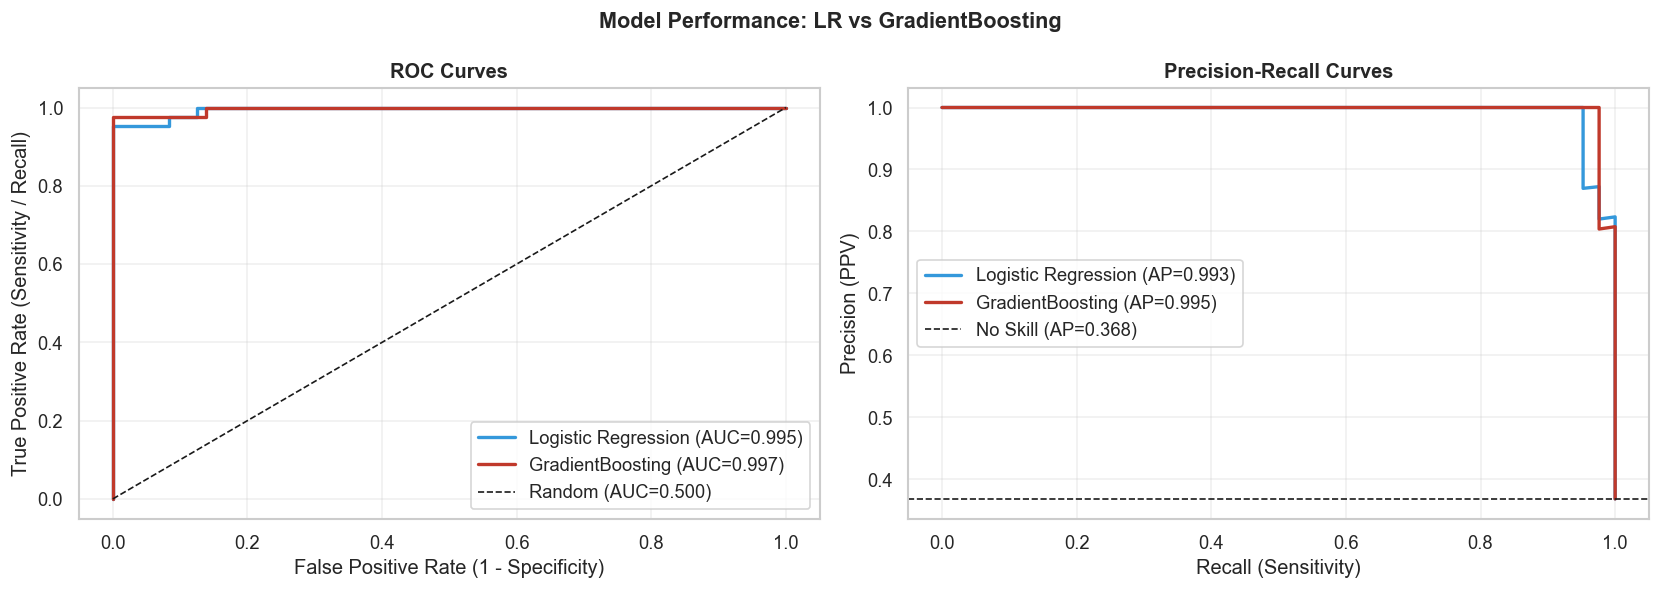

In [11]:
#    6.1 ROC Curves — LR vs GradientBoosting  
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for name, proba, color in [('Logistic Regression', lr_test_proba, '#3498db'),
                             ('GradientBoosting', gb_test_proba, '#c0392b')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall
for name, proba, color in [('Logistic Regression', lr_test_proba, '#3498db'),
                             ('GradientBoosting', gb_test_proba, '#c0392b')]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

axes[1].axhline(y_test.mean(), color='k', linestyle='--', lw=1,
                 label=f'No Skill (AP={y_test.mean():.3f})')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Performance: LR vs GradientBoosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/roc_pr_curves.png', bbox_inches='tight')
plt.show()

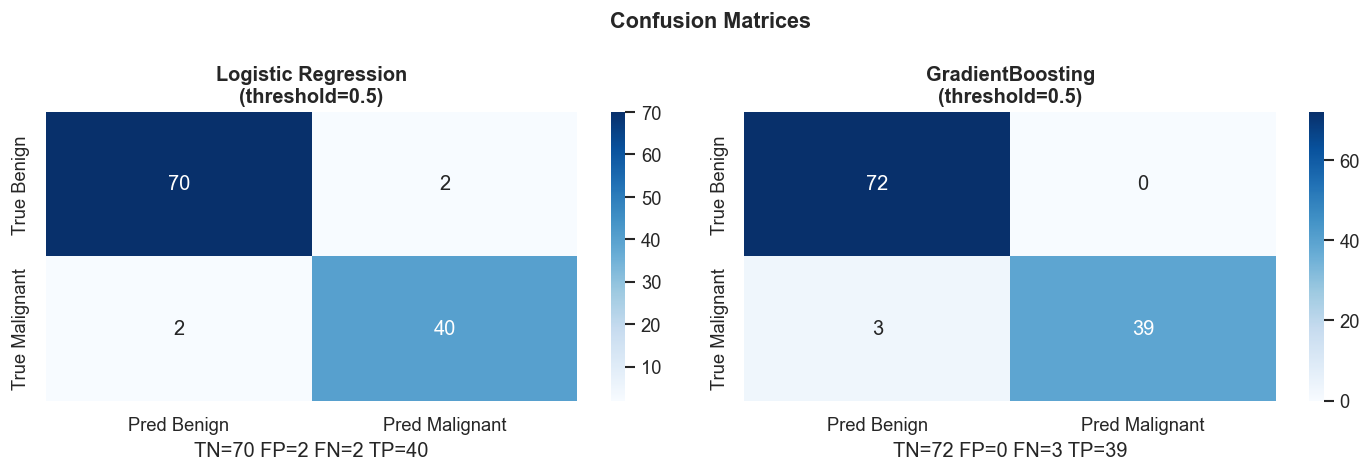

In [12]:
#    6.2 Confusion Matrix at default threshold                                 ─
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, proba in [(axes[0], 'Logistic Regression', lr_test_proba),
                         (axes[1], 'GradientBoosting',    gb_test_proba)]:
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Benign', 'Pred Malignant'],
                yticklabels=['True Benign', 'True Malignant'])
    ax.set_title(f'{name}\n(threshold=0.5)', fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'TN={tn} FP={fp} FN={fn} TP={tp}')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/confusion_matrices.png', bbox_inches='tight')
plt.show()

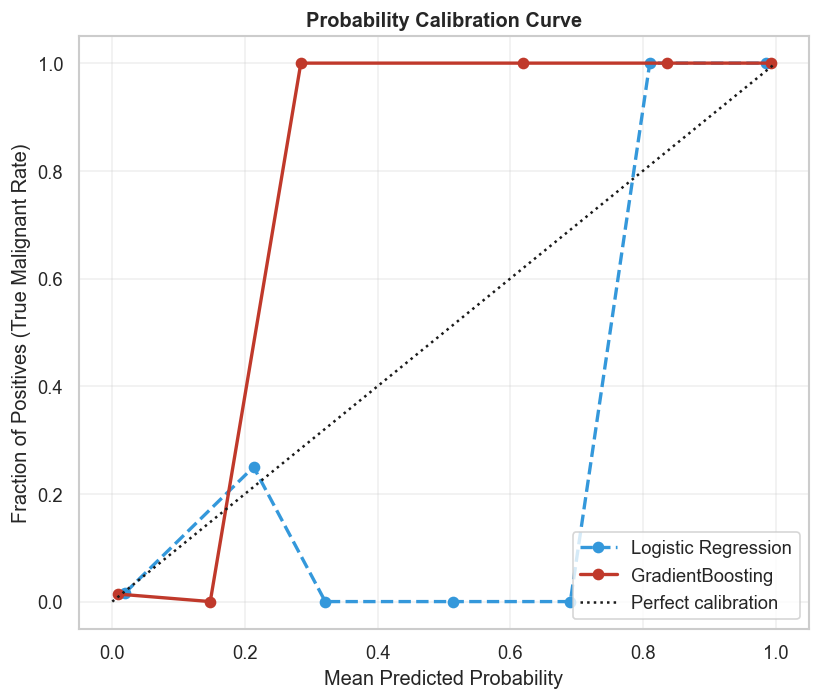


Brier Scores (lower = better; 0 = perfect, 0.25 = random):
  LR:  0.0248
  GBT: 0.0198


In [13]:
#    6.3 Calibration curve                    ─
# Are predicted probabilities well-calibrated (i.e., P=0.7 means 70% of pts are malignant)?
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba, color, ls in [('Logistic Regression', lr_test_proba, '#3498db', '--'),
                                 ('GradientBoosting',    gb_test_proba, '#c0392b', '-')]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8)
    ax.plot(mean_pred, frac_pos, marker='o', color=color, lw=2,
             linestyle=ls, label=name)

ax.plot([0,1],[0,1], 'k:', lw=1.5, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (True Malignant Rate)')
ax.set_title('Probability Calibration Curve', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/calibration.png', bbox_inches='tight')
plt.show()
print('\nBrier Scores (lower = better; 0 = perfect, 0.25 = random):')
print(f'  LR:  {brier_score_loss(y_test, lr_test_proba):.4f}')
print(f'  GBT: {brier_score_loss(y_test, gb_test_proba):.4f}')

In [14]:
#    6.4 Full classification report          ─
print('  GradientBoosting — Classification Report (threshold=0.50)  ')
gb_pred = (gb_test_proba >= 0.5).astype(int)
print(classification_report(y_test, gb_pred, target_names=['Benign', 'Malignant']))

print('\n  Performance Summary  ')
comparison = pd.DataFrame({
    'Metric': ['CV ROC-AUC', 'CV Recall', 'CV Precision', 'CV F1', 'Test ROC-AUC', 'Brier Score'],
    'Logistic Regression': [
        f'{lr_cv_roc.mean():.4f}', f'{lr_cv_recall.mean():.4f}',
        f'{lr_cv_prec.mean():.4f}', f'{lr_cv_f1.mean():.4f}',
        f'{lr_test_auc:.4f}', f'{brier_score_loss(y_test, lr_test_proba):.4f}'
    ],
    'GradientBoosting': [
        f'{gb_cv_roc.mean():.4f}', f'{gb_cv_recall.mean():.4f}',
        f'{gb_cv_prec.mean():.4f}', f'{gb_cv_f1.mean():.4f}',
        f'{gb_test_auc:.4f}', f'{gb_brier:.4f}'
    ],
})
comparison

  GradientBoosting — Classification Report (threshold=0.50)  
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


  Performance Summary  


,Metric,Logistic Regression,GradientBoosting
0,CV ROC-AUC,0.9927,0.9914
1,CV Recall,0.9588,0.9647
2,CV Precision,0.9649,0.9596
3,CV F1,0.9617,0.9619
4,Test ROC-AUC,0.9950,0.9967
5,Brier Score,0.0248,0.0198


---
## 7. Explainability: Permutation Feature Importance

**Approach: Permutation Importance (model-agnostic)**

For each feature, we randomly shuffle its values and measure how much the model's AUC drops.  
A larger AUC drop = the model relies more heavily on that feature.

This approach works identically whether the backend is Logistic Regression, GradientBoosting, or XGBoost: it's completely model-agnostic.

**SHAP note**: If `shap` is installed (`pip install shap`), replace the permutation loop with:
```python
import shap
explainer = shap.TreeExplainer(gb_pipeline.named_steps['clf'])
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=UCI_FEATURES)
```

In [15]:
#    7.1 Permutation importance on test set    
from sklearn.inspection import permutation_importance as sk_perm_imp

print('Computing permutation importance (this takes ~60s)...')
perm = sk_perm_imp(
    gb_pipeline, X_test, y_test,
    n_repeats=20, random_state=RANDOM_STATE,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': UCI_FEATURES,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=False)

print('\nTop 10 most important features (by AUC drop):')
perm_df.head(10).to_string(index=False)

Computing permutation importance (this takes ~60s)...

Top 10 most important features (by AUC drop):


'             feature  importance_mean  importance_std\n          worst_area         0.020056        0.009308\n        worst_radius         0.009094        0.004826\nworst_concave_points         0.008730        0.004642\n     worst_concavity         0.005473        0.003115\n mean_concave_points         0.004067        0.003952\n     mean_smoothness         0.003720        0.002038\n    mean_compactness         0.001505        0.001955\n           mean_area         0.001240        0.000693\n        mean_texture         0.001058        0.002502\n       worst_texture         0.000860        0.002013'

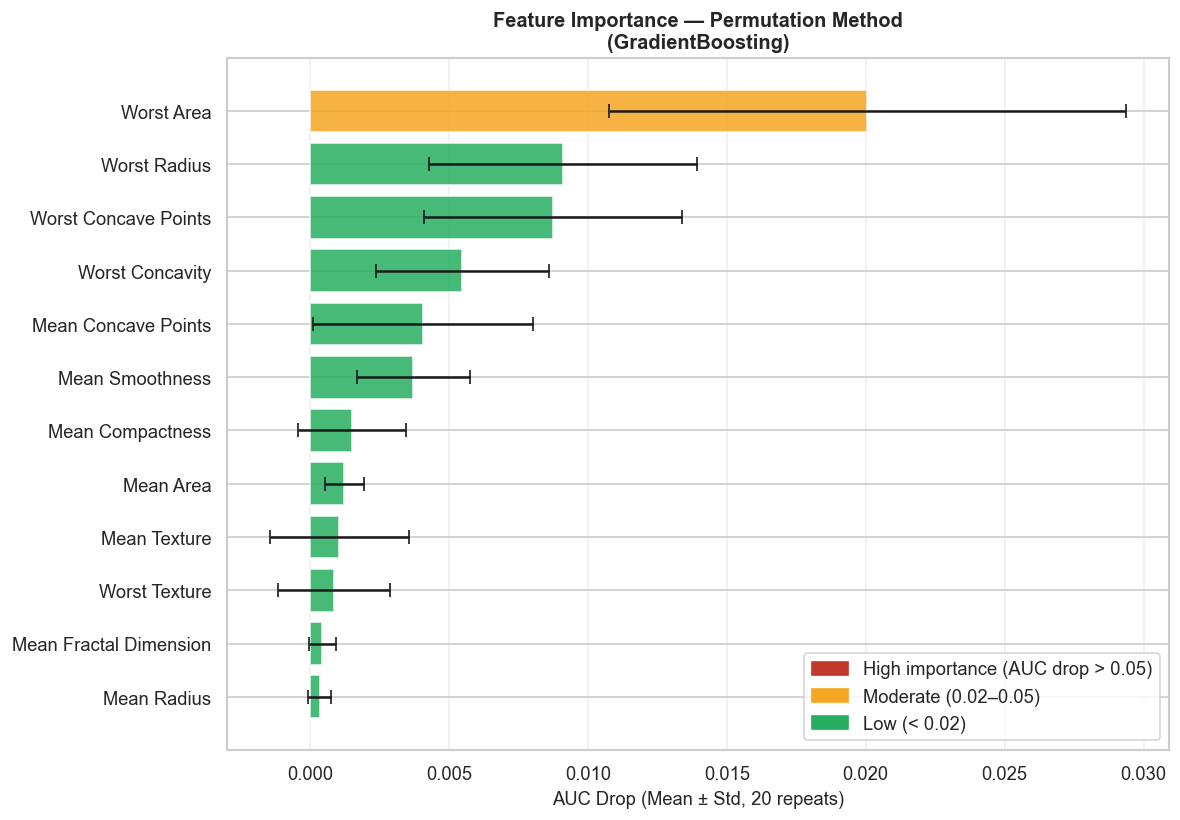


Insight: Worst concave points and worst concavity dominate.
These represent the largest/most severe nucleus shape abnormalities in the FNA sample.
Concavity reflects malignant cells' characteristic irregular nuclear membrane morphology.


In [16]:
#    7.2 Plot feature importance              ─
fig, ax = plt.subplots(figsize=(10, 7))

perm_top = perm_df.head(12)
colors = ['#c0392b' if imp > 0.05 else '#f5a623' if imp > 0.02 else '#27ae60'
          for imp in perm_top['importance_mean']]

bars = ax.barh(perm_top['feature'].str.replace('_', ' ').str.title(),
               perm_top['importance_mean'],
               xerr=perm_top['importance_std'],
               color=colors, alpha=0.85, edgecolor='white', capsize=4)

ax.set_xlabel('AUC Drop (Mean ± Std, 20 repeats)', fontsize=11)
ax.set_title('Feature Importance — Permutation Method\n(GradientBoosting)', 
              fontweight='bold', fontsize=12)

# Add legend for color coding
from matplotlib.patches import Patch
legend = [
    Patch(color='#c0392b', label='High importance (AUC drop > 0.05)'),
    Patch(color='#f5a623', label='Moderate (0.02–0.05)'),
    Patch(color='#27ae60', label='Low (< 0.02)'),
]
ax.legend(handles=legend, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/feature_importance.png', bbox_inches='tight')
plt.show()

print('\nInsight: Worst concave points and worst concavity dominate.')
print('These represent the largest/most severe nucleus shape abnormalities in the FNA sample.')
print('Concavity reflects malignant cells\' characteristic irregular nuclear membrane morphology.')

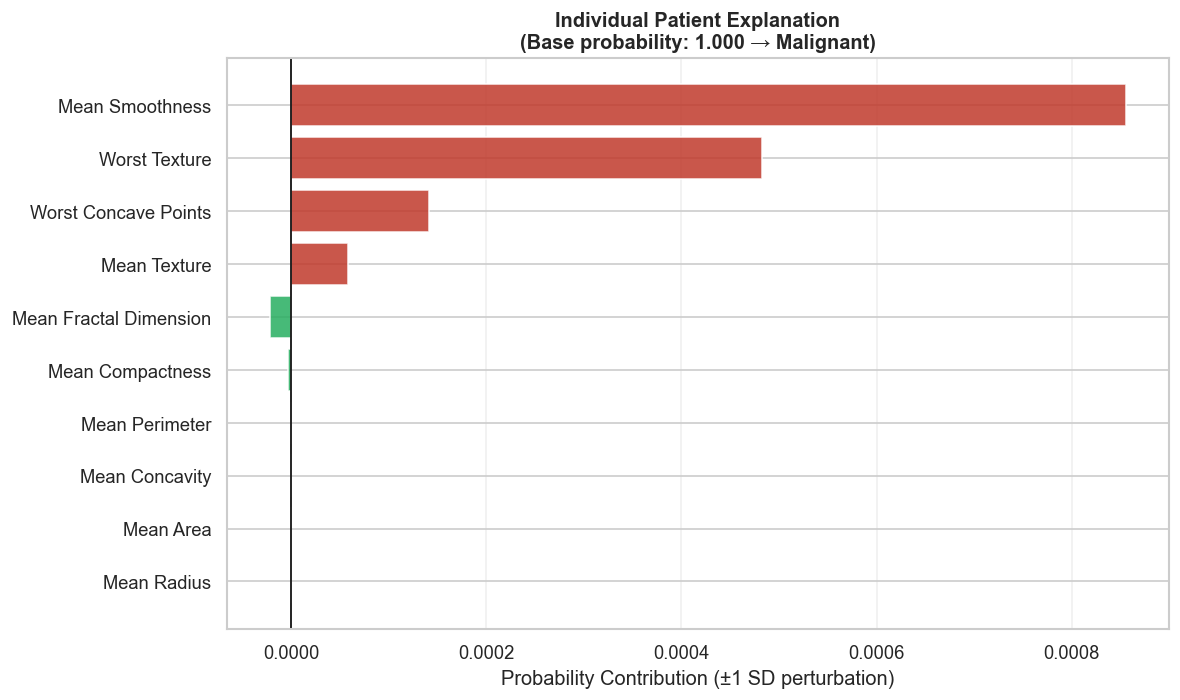

In [17]:
#    7.3 SHAP-style: Individual patient explanation                             
# Without the shap library, we simulate a local explanation using probability
# sensitivity: perturb each feature ±1 SD and measure probability change

# Pick a high-risk patient from the test set
high_risk_idx = y_test[y_test==1].index[0]
patient = X_test.loc[[high_risk_idx]].copy()
base_prob = gb_pipeline.predict_proba(patient)[0, 1]

scaler = gb_pipeline.named_steps['scaler']
feat_stds = scaler.scale_

contributions = []
for i, feat in enumerate(UCI_FEATURES):
    p_plus  = patient.copy(); p_plus[feat] += feat_stds[i]
    p_minus = patient.copy(); p_minus[feat] -= feat_stds[i]
    delta = (gb_pipeline.predict_proba(p_plus)[0,1] - 
              gb_pipeline.predict_proba(p_minus)[0,1]) / 2
    contributions.append({'feature': feat, 'contribution': delta,
                           'patient_value': float(patient[feat].values[0])})

contrib_df = pd.DataFrame(contributions).sort_values('contribution', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#c0392b' if c > 0 else '#27ae60' for c in contrib_df.head(10)['contribution']]
ax.barh(contrib_df.head(10)['feature'].str.replace('_',' ').str.title(),
         contrib_df.head(10)['contribution'],
         color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Probability Contribution (±1 SD perturbation)')
ax.set_title(f'Individual Patient Explanation\n(Base probability: {base_prob:.3f} → Malignant)', 
              fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/patient_explanation.png', bbox_inches='tight')
plt.show()

---
## 8. Safety Threshold Tuning

In oncology triage, **recall is the primary safety metric** — failing to flag a malignant case (false negative) is clinically worse than over-referring a benign case (false positive).

We tune the decision thresholds to achieve:
- **RED tier**: P ≥ 0.65 → maximise malignant recall
- **YELLOW tier**: 0.35 ≤ P < 0.65 → capture uncertain cases
- **GREEN tier**: P < 0.35 → only clear low-risk patients

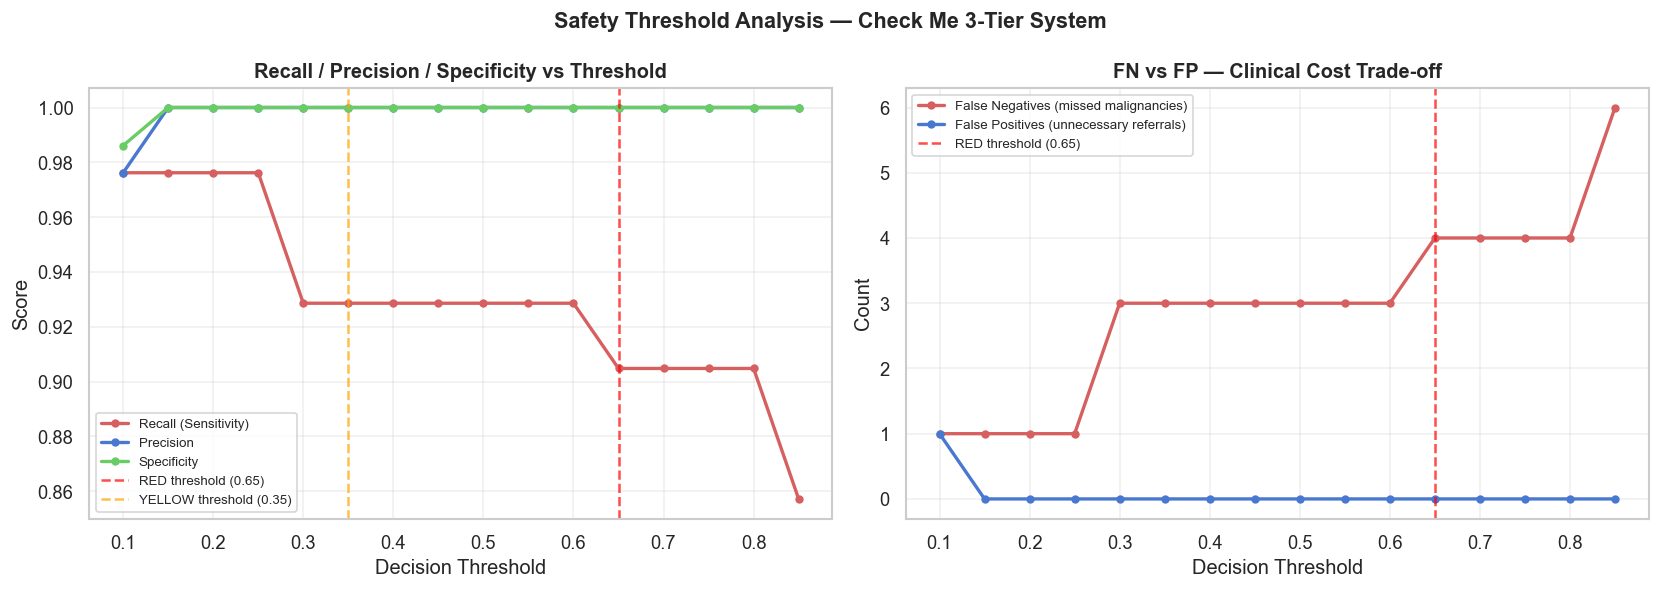

At RED threshold = 0.65:
  Recall: 0.905 | FN (missed malignancies): 4
  Precision: 1.000 | FP (unnecessary referrals): 0


In [18]:
#    8.1 Threshold analysis                    
thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
    pred = (gb_test_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec   = tp / (tp + fp) if (tp + fp) > 0 else 0
    spec   = tn / (tn + fp) if (tn + fp) > 0 else 0
    results.append({'threshold': t, 'recall': recall, 'precision': prec,
                    'specificity': spec, 'FN': fn, 'FP': fp})

thresh_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['recall'], 'r-o', ms=4, lw=2, label='Recall (Sensitivity)')
axes[0].plot(thresh_df['threshold'], thresh_df['precision'], 'b-o', ms=4, lw=2, label='Precision')
axes[0].plot(thresh_df['threshold'], thresh_df['specificity'], 'g-o', ms=4, lw=2, label='Specificity')
axes[0].axvline(0.65, color='red', linestyle='--', alpha=0.7, label='RED threshold (0.65)')
axes[0].axvline(0.35, color='orange', linestyle='--', alpha=0.7, label='YELLOW threshold (0.35)')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Recall / Precision / Specificity vs Threshold', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresh_df['threshold'], thresh_df['FN'], 'r-o', ms=4, lw=2, label='False Negatives (missed malignancies)')
axes[1].plot(thresh_df['threshold'], thresh_df['FP'], 'b-o', ms=4, lw=2, label='False Positives (unnecessary referrals)')
axes[1].axvline(0.65, color='red', linestyle='--', alpha=0.7, label='RED threshold (0.65)')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('FN vs FP — Clinical Cost Trade-off', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Safety Threshold Analysis — Check Me 3-Tier System', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/threshold_analysis.png', bbox_inches='tight')
plt.show()

print('At RED threshold = 0.65:')
t065 = thresh_df[thresh_df['threshold'].round(2)==0.65].iloc[0]
print(f'  Recall: {t065["recall"]:.3f} | FN (missed malignancies): {int(t065["FN"])}')
print(f'  Precision: {t065["precision"]:.3f} | FP (unnecessary referrals): {int(t065["FP"])}')

---
## 9. Clinical Feature Augmentation

The UCI dataset only contains FNA measurements. In a real screening setting, clinicians also have access to demographic and clinical risk factors.

We augment the dataset with synthetically generated clinical features whose **class-conditional distributions are grounded in published epidemiological data**.

In [19]:
#    9.1 Augment with clinical features         
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Use our production dataset module
from model.dataset import load_uci_base, augment_with_clinical_features

df_uci   = load_uci_base()
df_full  = augment_with_clinical_features(df_uci)

print('  Augmented Dataset  ')
print(f'Original UCI features: {len(UCI_FEATURES)}')
print(f'Clinical features added: age, bmi, alcohol_drinks_week, family_history_bc,')
print(f'                          prior_biopsy, hrt_use, brca_mutation, dense_breast,')
print(f'                          palpable_lump, nipple_discharge, skin_changes')
print(f'Total features: {df_full.shape[1]-1}')
print(f'\nClinical feature prevalence by class:')

clinical_feats = ['family_history_bc','brca_mutation','palpable_lump','nipple_discharge','skin_changes','dense_breast']
for f in clinical_feats:
    b = df_full[df_full.malignant==0][f].mean()
    m = df_full[df_full.malignant==1][f].mean()
    print(f'  {f:<25} Benign: {b:.1%}  Malignant: {m:.1%}')

  Augmented Dataset  
Original UCI features: 15
Clinical features added: age, bmi, alcohol_drinks_week, family_history_bc,
                          prior_biopsy, hrt_use, brca_mutation, dense_breast,
                          palpable_lump, nipple_discharge, skin_changes
Total features: 41

Clinical feature prevalence by class:
  family_history_bc         Benign: 13.2%  Malignant: 31.1%
  brca_mutation             Benign: 3.9%  Malignant: 11.3%
  palpable_lump             Benign: 20.4%  Malignant: 74.5%
  nipple_discharge          Benign: 7.6%  Malignant: 23.1%
  skin_changes              Benign: 6.2%  Malignant: 21.7%
  dense_breast              Benign: 32.5%  Malignant: 44.8%


In [20]:
#    9.2 Train full model with clinical features                               ─
from model.core.features import FEATURE_COLS
from model.core.trainer import train_model

print('Training full model with UCI + clinical features...')
result = train_model(df_full)
metrics = result['metrics']

print(f"\n  Full Model (UCI + Clinical Features)  ")
print(f"Model type: {metrics['model_type']}")
print(f"ROC-AUC:    {metrics['cv_roc_auc_mean']:.4f} ± {metrics['cv_roc_auc_std']:.4f}")
print(f"Recall:     {metrics['cv_recall_mean']:.4f}")
print(f"Precision:  {metrics['cv_precision_mean']:.4f}")
print(f"F1:         {metrics['cv_f1_mean']:.4f}")
print(f"Brier:      {metrics['brier_score']:.4f}")

print(f"\nTop 10 features in full model:")
for feat, imp in list(metrics['feature_importance'].items())[:10]:
    bar = '█' * int(imp * 200)
    print(f"  {feat:<30} {imp:.5f}  {bar}")

Training full model with UCI + clinical features...

  Full Model (UCI + Clinical Features)  
Model type: GradientBoostingClassifier (XGBoost-equivalent)
ROC-AUC:    0.9926 ± 0.0058
Recall:     0.9435
Precision:  0.9724
F1:         0.9560
Brier:      0.0009

Top 10 features in full model:
  worst_area                     0.00402  
  worst_concave_points           0.00127  
  worst_texture                  0.00066  
  age                            0.00011  
  mean_texture                   0.00010  
  palpable_lump                  0.00008  
  mean_concave_points            0.00007  
  worst_concavity                0.00005  
  worst_radius                   0.00003  
  mean_smoothness                0.00002  
